
# DeepSurv baseline in PyTorch

This notebook re-implements the **baseline DeepSurv** model in **PyTorch**.




## Notes
- This notebook uses a **repo-faithful Cox loss** based on sorting by decreasing survival time.
- It is a **baseline DeepSurv** only, without attention.
- It uses METABRIC dataset.
- Once this runs, it can be extended to **Attention-DeepSurv**.


In [ ]:
# =========================
# 1. Install / import packages
# =========================
!pip -q install lifelines pyarrow joblib

import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from lifelines.utils import concordance_index
from google.colab import drive


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.1 MB/s eta 0:00:00


In [ ]:

# =========================
# 2. Reproducibility
# =========================
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [ ]:

# =========================
# 3. Mount Google Drive
# =========================
drive.mount('/content/drive')


Mounted at /content/drive



## Set your dataset location

Update the path below after your teammate uploads the normalized METABRIC data to your shared Google Drive folder.

Examples:
- `/content/drive/MyDrive/ECEN766/METABRIC/metabric_normalized.npz`
- `/content/drive/MyDrive/ECEN766/METABRIC/`


In [ ]:
# =========================
# 4. Data path configuration
# =========================



DATA_DIR = "/content/drive/MyDrive/ECEN766final/Processed"



# Set this to False if the parquet features are already normalized

STANDARDIZE_IN_NOTEBOOK = False



assert os.path.exists(DATA_DIR), f"Folder not found: {DATA_DIR}"
print("Found data folder:", DATA_DIR)
print("Files:", sorted(os.listdir(DATA_DIR)))


Found data folder: /content/drive/MyDrive/ECEN766final/Processed
Files: ['X_test.parquet', 'X_train.parquet', 'X_val.parquet', 'scaler.pkl', 'y_test.parquet', 'y_train.parquet', 'y_val.parquet']


In [ ]:
# =========================
# 5. Data loading helpers
# =========================

import joblib

def _to_numpy(df_or_series):
    if hasattr(df_or_series, "to_numpy"):
        arr = df_or_series.to_numpy()
    else:
        arr = np.asarray(df_or_series)
    return arr

def _flatten_if_single_column(arr):
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr[:, 0]
    return arr

def _extract_time_event(y_df):
    """
    Flexible parser for y parquet files.

    Supported cases:
    1) Two columns with recognizable names, e.g.:
       - time/survival_time/os_time/months
       - event/status/e/os_event
    2) Exactly two columns -> assumes:
       first column = time, second column = event
    """
    if not isinstance(y_df, pd.DataFrame):
        y_df = pd.DataFrame(y_df)

    cols_lower = {c.lower(): c for c in y_df.columns}

    possible_time = [
        "time", "t", "duration", "survival_time", "overall_survival_time",
        "os_time", "months", "time_to_event"
    ]
    possible_event = [
        "event", "e", "status", "censor", "censored", "os_event",
        "overall_survival_event"
    ]

    time_col = None
    event_col = None

    for name in possible_time:
        if name in cols_lower:
            time_col = cols_lower[name]
            break

    for name in possible_event:
        if name in cols_lower:
            event_col = cols_lower[name]
            break

    if time_col is not None and event_col is not None:
        t = y_df[time_col].to_numpy(dtype=np.float32)
        e = y_df[event_col].to_numpy(dtype=np.float32)
        return t, e

    if y_df.shape[1] == 2:
        t = y_df.iloc[:, 0].to_numpy(dtype=np.float32)
        e = y_df.iloc[:, 1].to_numpy(dtype=np.float32)
        print("[Info] y parquet has 2 columns; assuming first=time, second=event.")
        return t, e

    raise ValueError(
        "Could not infer time/event columns from y parquet. "
        f"Found columns: {list(y_df.columns)}"
    )

def load_survival_data_from_parquet(data_dir: str):
    required = [
        "X_train.parquet", "X_val.parquet", "X_test.parquet",
        "y_train.parquet", "y_val.parquet", "y_test.parquet",
    ]
    for fname in required:
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing required file: {fpath}")

    X_train_df = pd.read_parquet(os.path.join(data_dir, "X_train.parquet"))
    X_val_df   = pd.read_parquet(os.path.join(data_dir, "X_val.parquet"))
    X_test_df  = pd.read_parquet(os.path.join(data_dir, "X_test.parquet"))

    y_train_df = pd.read_parquet(os.path.join(data_dir, "y_train.parquet"))
    y_val_df   = pd.read_parquet(os.path.join(data_dir, "y_val.parquet"))
    y_test_df  = pd.read_parquet(os.path.join(data_dir, "y_test.parquet"))

    t_train, e_train = _extract_time_event(y_train_df)
    t_val,   e_val   = _extract_time_event(y_val_df)
    t_test,  e_test  = _extract_time_event(y_test_df)

    train_data = {
        "x": _to_numpy(X_train_df).astype(np.float32),
        "t": t_train.astype(np.float32),
        "e": e_train.astype(np.float32),
    }
    val_data = {
        "x": _to_numpy(X_val_df).astype(np.float32),
        "t": t_val.astype(np.float32),
        "e": e_val.astype(np.float32),
    }
    test_data = {
        "x": _to_numpy(X_test_df).astype(np.float32),
        "t": t_test.astype(np.float32),
        "e": e_test.astype(np.float32),
    }

    feature_names = list(X_train_df.columns)

    shared_scaler = None
    scaler_path = os.path.join(data_dir, "scaler.pkl")
    if LOAD_SHARED_SCALER and os.path.exists(scaler_path):
        shared_scaler = joblib.load(scaler_path)
        print("Loaded teammate scaler from:", scaler_path)

    return train_data, val_data, test_data, feature_names, shared_scaler


In [ ]:
# =========================
# 6. Load the parquet data
# =========================
train_data, val_data, test_data, feature_names, shared_scaler = load_survival_data_from_parquet(DATA_DIR)

print("Train X shape:", train_data["x"].shape)
print("Val   X shape:", val_data["x"].shape)
print("Test  X shape:", test_data["x"].shape)

print("Train events:", int(np.sum(train_data["e"])))
print("Val events:", int(np.sum(val_data["e"])))
print("Test events:", int(np.sum(test_data["e"])))

print("Number of features:", len(feature_names))
print("First 10 feature names:", feature_names[:10])

print("\nSample y_train preview:")
display(pd.read_parquet(os.path.join(DATA_DIR, "y_train.parquet")).head())


Train X shape: (1386, 3000)
Val   X shape: (297, 3000)
Test  X shape: (297, 3000)
Train events: 799
Val events: 172
Test events: 171
Number of features: 3000
First 10 feature names: ['CTXN1', 'POFUT1', 'MRPL24', 'IDO1', 'CMIP', 'TUBGCP5', 'CLN8', 'SLC25A19', 'C5orf4', 'ZNF350']

Sample y_train preview:


Hugo_Symbol,time,event
MB-4849,45.333333,1
MB-0108,42.700000,1
MB-5157,18.233333,1
MB-0605,114.600000,0
MB-6122,260.200000,0


In [ ]:
%whos

Variable                          Type        Data/Info
-------------------------------------------------------
DATA_DIR                          str         /content/drive/MyDrive/ECEN766final/Processed
DEVICE                            str         cpu
LOAD_SHARED_SCALER                bool        False
Path                              type        <class 'pathlib.Path'>
SEED                              int         42
STANDARDIZE_IN_NOTEBOOK           bool        False
concordance_index                 function    <function concordance_index at 0x7a1dfb3244a0>
drive                             module      <module 'google.colab.dri<...>s/google/colab/drive.py'>
feature_names                     list        n=3000
joblib                            module      <module 'joblib' from '/u<...>ages/joblib/__init__.py'>
load_survival_data_from_parquet   function    <function load_survival_d<...>arquet at 0x7a1dfa974540>
math                              module      <module 'math' (built-in)>

In [ ]:
# Debug non-finite values in loaded x arrays
for split_name, data_dict in [("train", train_data), ("val", val_data), ("test", test_data)]:
    x = data_dict["x"]
    t = data_dict["t"]
    e = data_dict["e"]

    n_nan = np.isnan(x).sum()
    n_posinf = np.isposinf(x).sum()
    n_neginf = np.isneginf(x).sum()
    total_bad = n_nan + n_posinf + n_neginf

    print(f"{split_name}:")
    print(f"  x shape      = {x.shape}")
    print(f"  NaN count    = {n_nan}")
    print(f"  +inf count   = {n_posinf}")
    print(f"  -inf count   = {n_neginf}")
    print(f"  total bad    = {total_bad}")

    if total_bad > 0:
        bad_rows = np.where(~np.isfinite(x).all(axis=1))[0]
        bad_cols = np.where(~np.isfinite(x).all(axis=0))[0]

        print(f"  bad row indices (first 20): {bad_rows[:20]}")
        print(f"  bad col indices (first 20): {bad_cols[:20]}")

    print()

train:
  x shape      = (1386, 3000)
  NaN count    = 10
  +inf count   = 0
  -inf count   = 0
  total bad    = 10
  bad row indices (first 20): [ 196  245  440  445  574  679  680  681  734 1269]
  bad col indices (first 20): [0 1 2 3 4 5 6 7]

val:
  x shape      = (297, 3000)
  NaN count    = 1
  +inf count   = 0
  -inf count   = 0
  total bad    = 1
  bad row indices (first 20): [148]
  bad col indices (first 20): [4]

test:
  x shape      = (297, 3000)
  NaN count    = 2
  +inf count   = 0
  -inf count   = 0
  total bad    = 2
  bad row indices (first 20): [124 232]
  bad col indices (first 20): [1 7]



In [ ]:
def impute_with_train_medians(train_data, val_data, test_data):
    x_train = train_data["x"].copy()
    x_val = val_data["x"].copy()
    x_test = test_data["x"].copy()

    print("Bad values before imputation:")
    print("  train:", np.isnan(x_train).sum())
    print("  val:  ", np.isnan(x_val).sum())
    print("  test: ", np.isnan(x_test).sum())

    # Compute medians from training set only
    train_medians = np.nanmedian(x_train, axis=0)

    # If a whole training column were NaN, fallback to 0.0
    train_medians = np.where(np.isfinite(train_medians), train_medians, 0.0)

    def fill_nan_with_reference_medians(x, medians):
        inds = np.where(np.isnan(x))
        if len(inds[0]) > 0:
            x[inds] = np.take(medians, inds[1])
        return x

    x_train = fill_nan_with_reference_medians(x_train, train_medians)
    x_val = fill_nan_with_reference_medians(x_val, train_medians)
    x_test = fill_nan_with_reference_medians(x_test, train_medians)

    train_data = train_data.copy()
    val_data = val_data.copy()
    test_data = test_data.copy()

    train_data["x"] = x_train
    val_data["x"] = x_val
    test_data["x"] = x_test

    print("\nBad values after imputation:")
    print("  train:", np.isnan(train_data["x"]).sum())
    print("  val:  ", np.isnan(val_data["x"]).sum())
    print("  test: ", np.isnan(test_data["x"]).sum())

    return train_data, val_data, test_data


train_data, val_data, test_data = impute_with_train_medians(train_data, val_data, test_data)

Bad values before imputation:
  train: 10
  val:   1
  test:  2

Bad values after imputation:
  train: 0
  val:   0
  test:  0


In [ ]:

# =========================
# 7. Sanity checks
# =========================
def check_data_dict(data_dict, name="data"):
    x, t, e = data_dict["x"], data_dict["t"], data_dict["e"]
    assert len(x) == len(t) == len(e), f"{name}: mismatched lengths"
    assert np.isfinite(x).all(), f"{name}: x has non-finite values"
    assert np.isfinite(t).all(), f"{name}: t has non-finite values"
    assert np.isfinite(e).all(), f"{name}: e has non-finite values"
    assert set(np.unique(e)).issubset({0.0, 1.0}), f"{name}: e must contain only 0/1"
    assert np.all(t >= 0), f"{name}: survival times must be non-negative"

check_data_dict(train_data, "train")
check_data_dict(val_data, "val")
if test_data is not None:
    check_data_dict(test_data, "test")

print("All data checks passed.")


All data checks passed.


In [ ]:

# =========================
# 8. Standardization helper
# =========================
class Standardizer:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, x: torch.Tensor):
        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True).clamp_min(1e-8)

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) / self.std


In [ ]:

# =========================
# 9. Sorting helper
# =========================
def sort_by_time_desc(x: torch.Tensor, t: torch.Tensor, e: torch.Tensor):
    idx = torch.argsort(t, descending=True)
    return x[idx], t[idx], e[idx]


In [ ]:

# =========================
# 10. DeepSurv model
# =========================
class DeepSurvTorch(nn.Module):
    def __init__(
        self,
        n_in: int,
        hidden_layers_sizes=(128, 64),
        dropout=0.3,
        batch_norm=False,
    ):
        super().__init__()

        layers = []
        in_dim = n_in

        for h in hidden_layers_sizes:
            layers.append(nn.Linear(in_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout is not None and dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)



## Cox loss

This is a **baseline DeepSurv-style Cox partial likelihood loss** that assumes the batch is sorted by decreasing survival time.

Note: this is the simple repo-faithful baseline and does **not explicitly handle tied event times** with Breslow/Efron corrections.


In [ ]:

# =========================
# 11. Cox partial likelihood loss
# =========================
def cox_ph_loss(log_hz: torch.Tensor, event: torch.Tensor) -> torch.Tensor:
    log_hz = log_hz.reshape(-1)
    event = event.reshape(-1).float()

    log_cum_risk = torch.logcumsumexp(log_hz, dim=0)
    losses = event * (log_cum_risk - log_hz)

    n_events = event.sum().clamp_min(1.0)
    return losses.sum() / n_events


In [ ]:

# =========================
# 12. Utility: c-index evaluation
# =========================
def evaluate_cindex(model, data, scaler=None, device="cpu"):
    model.eval()

    x = torch.tensor(data["x"], dtype=torch.float32, device=device)
    t = torch.tensor(data["t"], dtype=torch.float32, device=device)
    e = torch.tensor(data["e"], dtype=torch.float32, device=device)

    if scaler is not None:
        x = scaler.transform(x)

    with torch.no_grad():
        pred = model(x).detach().cpu().numpy()

    return concordance_index(
        t.detach().cpu().numpy(),
        -pred,  # higher risk should correspond to shorter survival
        e.detach().cpu().numpy()
    )


In [ ]:

# =========================
# 13. Training loop
# =========================
def train_deepsurv(
    model,
    train_data,
    valid_data=None,
    n_epochs=300,
    learning_rate=1e-3,
    lr_decay=0.0,
    momentum=0.9,
    l2_reg=0.0,
    standardize=True,
    device="cpu",
    verbose_every=25,
):
    model.to(device)

    x_train = torch.tensor(train_data["x"], dtype=torch.float32, device=device)
    t_train = torch.tensor(train_data["t"], dtype=torch.float32, device=device)
    e_train = torch.tensor(train_data["e"], dtype=torch.float32, device=device)

    scaler = None
    if standardize:
        scaler = Standardizer()
        scaler.fit(x_train)
        x_train = scaler.transform(x_train)

    x_train, t_train, e_train = sort_by_time_desc(x_train, t_train, e_train)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum,
        nesterov=True,
    )

    history = []

    for epoch in range(1, n_epochs + 1):
        model.train()

        lr = learning_rate / (1.0 + (epoch - 1) * lr_decay)
        for g in optimizer.param_groups:
            g["lr"] = lr

        optimizer.zero_grad()
        log_hz = model(x_train)
        loss = cox_ph_loss(log_hz, e_train)

        if l2_reg > 0:
            l2_pen = sum((p ** 2).sum() for p in model.parameters())
            loss = loss + l2_reg * l2_pen

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_train = model(x_train).detach().cpu().numpy()
            train_ci = concordance_index(
                t_train.detach().cpu().numpy(),
                -pred_train,
                e_train.detach().cpu().numpy()
            )

        row = {
            "epoch": epoch,
            "loss": float(loss.item()),
            "train_cindex": float(train_ci),
            "lr": float(lr),
        }

        if valid_data is not None:
            x_val = torch.tensor(valid_data["x"], dtype=torch.float32, device=device)
            t_val = torch.tensor(valid_data["t"], dtype=torch.float32, device=device)
            e_val = torch.tensor(valid_data["e"], dtype=torch.float32, device=device)

            if scaler is not None:
                x_val = scaler.transform(x_val)

            with torch.no_grad():
                pred_val = model(x_val).detach().cpu().numpy()
                val_ci = concordance_index(
                    t_val.detach().cpu().numpy(),
                    -pred_val,
                    e_val.detach().cpu().numpy()
                )
            row["val_cindex"] = float(val_ci)

        history.append(row)

        if (epoch == 1) or (epoch % verbose_every == 0) or (epoch == n_epochs):
            msg = f"Epoch {epoch:03d} | loss={row['loss']:.4f} | train_c={row['train_cindex']:.4f}"
            if "val_cindex" in row:
                msg += f" | val_c={row['val_cindex']:.4f}"
            print(msg)

    return pd.DataFrame(history), scaler


In [ ]:
# =========================
# 14. Hyperparameters
# =========================
N_FEATURES = train_data["x"].shape[1]

HIDDEN_LAYERS = (128, 64)
DROPOUT = 0.3
BATCH_NORM = False

N_EPOCHS = 300
LEARNING_RATE = 1e-3
LR_DECAY = 0.0
MOMENTUM = 0.9
L2_REG = 1e-4

# Use False if the parquet features were already normalized.
STANDARDIZE = STANDARDIZE_IN_NOTEBOOK

print("Number of input features:", N_FEATURES)
print("Standardize inside notebook:", STANDARDIZE)


Number of input features: 3000
Standardize inside notebook: False


In [ ]:

# =========================
# 15. Initialize and train model
# =========================
model = DeepSurvTorch(
    n_in=N_FEATURES,
    hidden_layers_sizes=HIDDEN_LAYERS,
    dropout=DROPOUT,
    batch_norm=BATCH_NORM,
)

history_df, scaler = train_deepsurv(
    model=model,
    train_data=train_data,
    valid_data=val_data,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    lr_decay=LR_DECAY,
    momentum=MOMENTUM,
    l2_reg=L2_REG,
    standardize=STANDARDIZE,
    device=DEVICE,
    verbose_every=25,
)


Epoch 001 | loss=6.5540 | train_c=0.4829 | val_c=0.4477
Epoch 025 | loss=6.5195 | train_c=0.5862 | val_c=0.5001
Epoch 050 | loss=6.4891 | train_c=0.6554 | val_c=0.5466
Epoch 075 | loss=6.4566 | train_c=0.6900 | val_c=0.5701
Epoch 100 | loss=6.4193 | train_c=0.7159 | val_c=0.5843
Epoch 125 | loss=6.3791 | train_c=0.7388 | val_c=0.5953
Epoch 150 | loss=6.3191 | train_c=0.7621 | val_c=0.6040
Epoch 175 | loss=6.2563 | train_c=0.7862 | val_c=0.6136
Epoch 200 | loss=6.1748 | train_c=0.8119 | val_c=0.6216
Epoch 225 | loss=6.0767 | train_c=0.8374 | val_c=0.6279
Epoch 250 | loss=5.9463 | train_c=0.8629 | val_c=0.6324
Epoch 275 | loss=5.7986 | train_c=0.8874 | val_c=0.6347
Epoch 300 | loss=5.6533 | train_c=0.9082 | val_c=0.6303


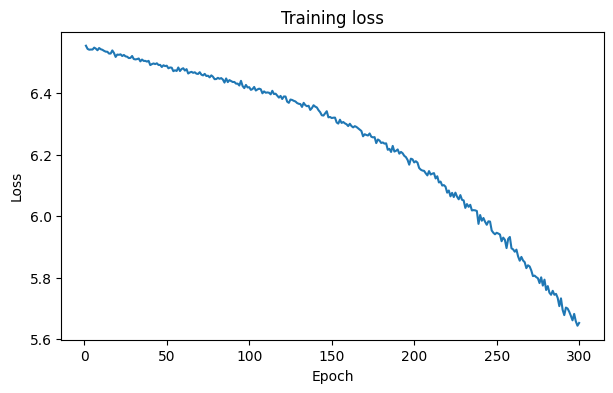

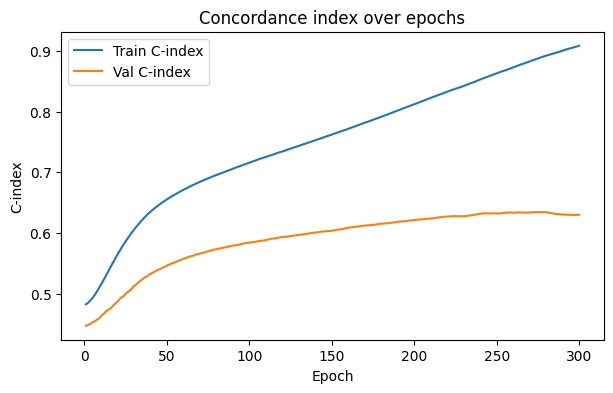

,epoch,loss,train_cindex,lr,val_cindex
295,296,5.661870,0.905057,0.001,0.629706
296,297,5.682710,0.905742,0.001,0.629674
297,298,5.658559,0.906490,0.001,0.629937
298,299,5.644312,0.907416,0.001,0.629937
299,300,5.653294,0.908232,0.001,0.630299


In [ ]:

# =========================
# 16. Plot training history
# =========================
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_cindex"], label="Train C-index")
if "val_cindex" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_cindex"], label="Val C-index")
plt.xlabel("Epoch")
plt.ylabel("C-index")
plt.title("Concordance index over epochs")
plt.legend()
plt.show()

history_df.tail()


In [ ]:

# =========================
# 17. Final evaluation
# =========================
train_ci = evaluate_cindex(model, train_data, scaler=scaler, device=DEVICE)
val_ci = evaluate_cindex(model, val_data, scaler=scaler, device=DEVICE)

print(f"Final Train C-index: {train_ci:.4f}")
print(f"Final Val   C-index: {val_ci:.4f}")

if test_data is not None:
    test_ci = evaluate_cindex(model, test_data, scaler=scaler, device=DEVICE)
    print(f"Final Test  C-index: {test_ci:.4f}")


Final Train C-index: 0.9082
Final Val   C-index: 0.6303
Final Test  C-index: 0.6543


In [ ]:
# =========================
# 18. Save model, scaler, and training history
# =========================
OUTPUT_DIR = "/content/drive/MyDrive/ECEN766/DeepSurv_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_path = os.path.join(OUTPUT_DIR, "deepsurv_baseline_model.pt")
history_path = os.path.join(OUTPUT_DIR, "deepsurv_training_history.csv")
feature_names_path = os.path.join(OUTPUT_DIR, "feature_names.txt")
scaler_path = os.path.join(OUTPUT_DIR, "deepsurv_scaler.npz")

torch.save(model.state_dict(), model_path)
history_df.to_csv(history_path, index=False)

with open(feature_names_path, "w") as f:
    for name in feature_names:
        f.write(f"{name}\n")

if scaler is not None:
    np.savez(
        scaler_path,
        mean=scaler.mean.detach().cpu().numpy(),
        std=scaler.std.detach().cpu().numpy(),
    )

print("Saved model to:", model_path)
print("Saved history to:", history_path)
print("Saved feature names to:", feature_names_path)
if scaler is not None:
    print("Saved scaler to:", scaler_path)
else:
    print("No notebook scaler saved because STANDARDIZE=False.")


Saved model to: /content/drive/MyDrive/ECEN766/DeepSurv_outputs/deepsurv_baseline_model.pt
Saved history to: /content/drive/MyDrive/ECEN766/DeepSurv_outputs/deepsurv_training_history.csv
Saved feature names to: /content/drive/MyDrive/ECEN766/DeepSurv_outputs/feature_names.txt
No notebook scaler saved because STANDARDIZE=False.
